In [2]:
import pandas as pd

import matplotlib.pyplot as plt

# df = pd.read_csv("./combined.csv", dtypes=)
df = pd.read_csv("./combined.csv")

In [3]:
df

,State Code,County Code,Site Number,Parameter Code,POC,Latitude,Longitude,Datum,Parameter Name,Duration Description,...,99th Perecentile,Method Count,Tribe Name,State Name,County Name,City Name,Local Site Name,Address,MSA or CBSA Name,Data Source
0,49,035,3006,88101,1,40.736389,-111.872222,WGS84,PM2.5 - Local Conditions,24 HOUR,...,49.6,1,NaN,Utah,Salt Lake,Salt Lake City,Hawthorne,"1675 SOUTH 600 EAST, SALT LAKE CITY","Salt Lake City, UT",AQS Data Mart
1,49,035,3006,88101,1,40.736389,-111.872222,WGS84,PM2.5 - Local Conditions,24 HOUR,...,49.6,1,NaN,Utah,Salt Lake,Salt Lake City,Hawthorne,"1675 SOUTH 600 EAST, SALT LAKE CITY","Salt Lake City, UT",AQS Data Mart
2,49,035,3006,42602,1,40.736389,-111.872222,WGS84,Nitrogen dioxide (NO2),1 HOUR,...,84,1,NaN,Utah,Salt Lake,Salt Lake City,Hawthorne,"1675 SOUTH 600 EAST, SALT LAKE CITY","Salt Lake City, UT",AQS Data Mart
3,49,035,3006,42602,1,40.736389,-111.872222,WGS84,Nitrogen dioxide (NO2),1 HOUR,...,61,1,NaN,Utah,Salt Lake,Salt Lake City,Hawthorne,"1675 SOUTH 600 EAST, SALT LAKE CITY","Salt Lake City, UT",AQS Data Mart
4,49,035,3006,44201,1,40.736389,-111.872222,WGS84,Ozone,1 HOUR,...,0.108,1,NaN,Utah,Salt Lake,Salt Lake City,Hawthorne,"1675 SOUTH 600 EAST, SALT LAKE CITY","Salt Lake City, UT",AQS Data Mart
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3380,49,035,3006,81102,4,40.736389,-111.872222,WGS84,PM10 Total 0-10um STP,24-HR BLK AVG,...,46,1,NaN,Utah,Salt Lake,Salt Lake City,Hawthorne,"1675 SOUTH 600 EAST, SALT LAKE CITY","Salt Lake City, UT",AQS Data Mart
3381,49,035,3006,42401,1,40.736389,-111.872222,WGS84,Sulfur dioxide,3-HR BLK AVG,...,2,1,NaN,Utah,Salt Lake,Salt Lake City,Hawthorne,"1675 SOUTH 600 EAST, SALT LAKE CITY","Salt Lake City, UT",AQS Data Mart
3382,49,035,3006,42101,1,40.736389,-111.872222,WGS84,Carbon monoxide,8-HR RUN AVG END HOUR,...,0.5,1,NaN,Utah,Salt Lake,Salt Lake City,Hawthorne,"1675 SOUTH 600 EAST, SALT LAKE CITY","Salt Lake City, UT",AQS Data Mart
3383,49,035,3006,42401,2,40.736389,-111.872222,WGS84,Sulfur dioxide,5 MINUTE,...,2.2,1,NaN,Utah,Salt Lake,Salt Lake City,Hawthorne,"1675 SOUTH 600 EAST, SALT LAKE CITY","Salt Lake City, UT",AQS Data Mart


(56, 10)


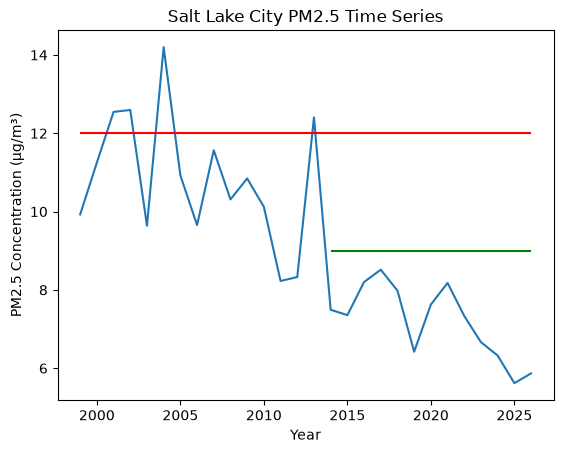

In [ ]:


df = df[['Parameter Code', 'POC', 'Parameter Name', 'Duration Description', 'Year', 'Units of Measure', 'Observation Count', 'Valid Day Count', 'Arithmetic Mean', "Required Day Count"]]

#filter for proper POC -> specific measuring method on site, or specific monitor on site
#df = df[df['POC'] == "5"]

#filter for local PM2.5 data only
df = df[df["Parameter Name"] == "PM2.5 - Local Conditions"]

#filter for PPM measurements only
df = df[df['Units of Measure'] == "Micrograms/cubic meter (LC)"]

#remove the header row that is being read in the data, most likely from hasty combining of the csv files through
#the command line interface
df = df[df["Year"] != "Year"]

#sort the dataframe by year in ascending order so that the time series plot will be correct
df = df.sort_values(["Year"], ascending=True)

#sorting so that my dataframe only includes what I need for the time series plot

# df = df[['Year', 'Arithmetic Mean']]

#converting the Year and Arithmetic Mean columns to numeric values so that I can plot them
#why are they strings ;(

df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df['Arithmetic Mean'] = pd.to_numeric(df['Arithmetic Mean'], errors='coerce')

df = df[df['Arithmetic Mean'].apply(lambda x: isinstance(x, (int, float)))]

df = df[df["Duration Description"] == "24 HOUR"]

#print(df.head())

#print(df())

print(df.shape)

#plot looks pretty darn good! just gotta filter for proper POC, remove duplicate data, and fit some horizontal lines to show old and new EPA reqs


plt.plot(df["Year"], df["Arithmetic Mean"])
plt.title("Salt Lake City PM2.5 Time Series")
plt.xlabel("Year")
plt.ylabel("PM2.5 Concentration (µg/m³)")
#add in a legend describing the hlines
plt.hlines(
    y=12,xmin=1999, xmax=2026, colors="red", label= "old EPA PM-2.5 requirement"
)
plt.hlines(
    y=9, xmin=2014, xmax = 2026, colors = "green", label = "new EPA PM-2.5 requirement"
)
plt.show()

In [17]:
df

,Parameter Code,POC,Parameter Name,Duration Description,Year,Units of Measure,Observation Count,Valid Day Count,Arithmetic Mean
0,88101,1,PM2.5 - Local Conditions,24 HOUR,1999,Micrograms/cubic meter (LC),315,315,9.926349
1,88101,1,PM2.5 - Local Conditions,24 HOUR,1999,Micrograms/cubic meter (LC),315,315,9.926349
150,88101,1,PM2.5 - Local Conditions,24 HOUR,2000,Micrograms/cubic meter (LC),329,329,11.250456
158,88101,1,PM2.5 - Local Conditions,24 HOUR,2000,Micrograms/cubic meter (LC),329,329,11.250456
201,88101,1,PM2.5 - Local Conditions,24 HOUR,2001,Micrograms/cubic meter (LC),339,339,12.546018
225,88101,1,PM2.5 - Local Conditions,24 HOUR,2001,Micrograms/cubic meter (LC),339,339,12.546018
283,88101,1,PM2.5 - Local Conditions,24 HOUR,2002,Micrograms/cubic meter (LC),358,358,12.595251
284,88101,1,PM2.5 - Local Conditions,24 HOUR,2002,Micrograms/cubic meter (LC),358,358,12.595251
376,88101,1,PM2.5 - Local Conditions,24 HOUR,2003,Micrograms/cubic meter (LC),353,353,9.639093
377,88101,1,PM2.5 - Local Conditions,24 HOUR,2003,Micrograms/cubic meter (LC),353,353,9.639093
